## 2. Analisi del Dataset Titanic

In [1]:
%conda install pandas
%conda install matplotlib
%conda install seaborn

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current ve

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


1. Quante righe e colonne ha il dataset?
    Il dataset ha 891 righe e 12 colonne

In [3]:
df.shape

(891, 12)

2. Controlla quanti valori mancanti ci sono per colonna

In [4]:
abs(df.count() - 891)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

3. Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente

In [5]:
# Calcolo la moda di embarked
embarked_mode = df['Embarked'].mode()[0]

# Assegno la moda alle righe che hanno NaN su Embarked
df.loc[df['Embarked'].isna(), 'Embarked'] = embarked_mode

len(df[df['Embarked'].isna()])

0

4. Controlla se ci sono righe duplicate

In [6]:
len(df[df.duplicated()])       # Non ci sono righe duplicate

0

5. Calcola l'età media dei passeggeri per ogni classe (Pclass), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio

In [7]:
avg_age = df.groupby('Pclass')['Age'].mean()
avg_age

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [8]:
for i in range(1, len(avg_age) + 1):
    df.loc[(df['Age'].isna()) & (df['Pclass'] == i), 'Age'] = avg_age[i]

len(df[df['Age'].isna()])

0

6. Visualizza la distribuzione dell'età per classe

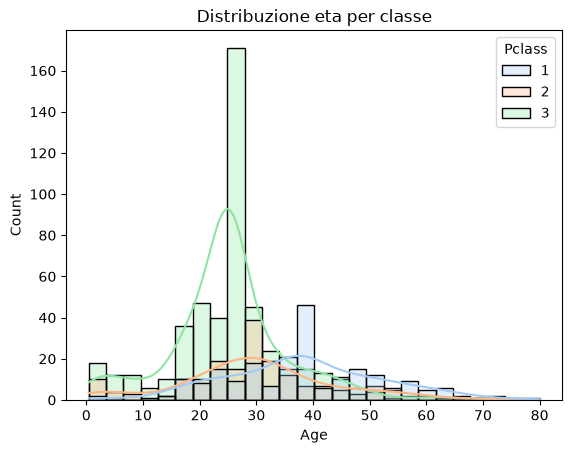

In [23]:
sns.histplot(data=df, x='Age', hue='Pclass', kde=True, alpha=0.3, palette='pastel')
plt.title('Distribuzione eta per classe')
plt.show()

7. Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

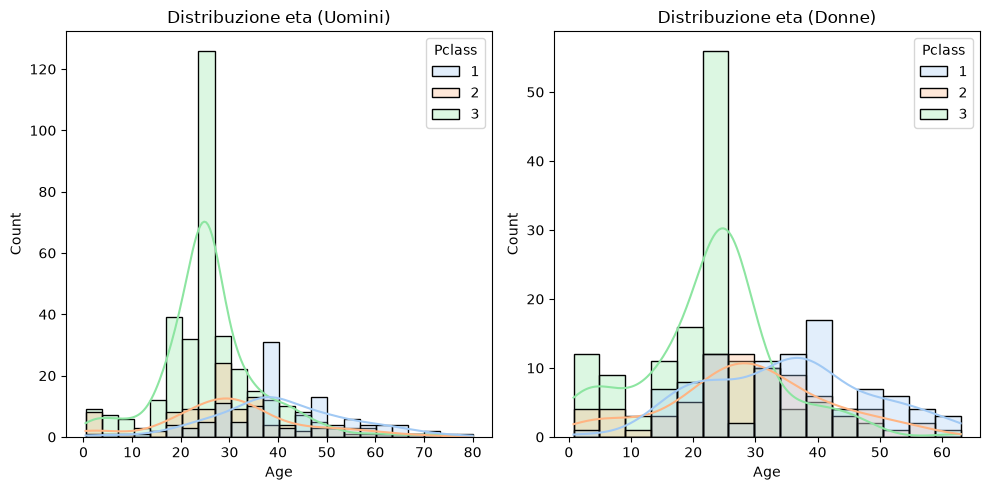

In [30]:
# Creo due dataframe uno solo con i dati per gli uomini e uno per le donne
men_df = df[df['Sex'] == 'male']
women_df = df[df['Sex'] == 'female']

# Creo due subplot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Primo subplot
sns.histplot(data=men_df, x='Age', hue='Pclass', kde=True, alpha=0.3, palette='pastel', ax=ax[0])
ax[0].set_title('Distribuzione eta (Uomini)')

# Secondo subplot
sns.histplot(data=women_df, x='Age', hue='Pclass', kde=True, alpha=0.3, palette='pastel', ax=ax[1])
ax[1].set_title('Distribuzione eta (Donne)')

plt.tight_layout()
plt.show()